In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # move up from /notebooks to project root
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("project_root:", project_root)

project_root: /Users/mihirgaudani/trader-joes-nyc-case-study


In [2]:
# 05_visualization_and_export.ipynb

from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from src.config import PROCESSED_DIR, TABLES_DIR, FIGS_DIR, MAPS_DIR



# Explicitly load finalized artifacts from prior notebooks
score_df = gpd.read_file(PROCESSED_DIR / "nyc_scored_candidates.geojson")
top10_refine_df = gpd.read_file(PROCESSED_DIR / "top10_refinement_table.geojson")

# Safety checks
print(score_df.shape)
print(top10_refine_df.shape)
print(score_df.columns.tolist())
print(top10_refine_df.columns.tolist())

(93, 20)
(10, 30)
['zip_code', 'boroname', 'total_population', 'median_household_income', 'median_household_income_filled', 'nearest_tj_distance_miles', 'subway_station_count', 'area_sq_miles', 'population_density', 'income_percentile', 'transit_access_tier', 'is_tj_gap', 'log_population_density', 'density_score', 'income_score', 'tj_gap_score', 'transit_score', 'site_selection_score', 'rank', 'geometry']
['zip_code', 'boroname', 'total_population', 'median_household_income', 'median_household_income_filled', 'nearest_tj_distance_miles', 'subway_station_count', 'area_sq_miles', 'population_density', 'income_percentile', 'transit_access_tier', 'is_tj_gap', 'log_population_density', 'density_score', 'income_score', 'tj_gap_score', 'transit_score', 'site_selection_score', 'rank', 'nearest_competitor_ft', 'nearest_competitor_miles', 'competitor_count_1mi', 'avg_asking_rent_psf', 'retail_corridor_proxy', 'rent_score', 'competition_score', 'tj_customer_fit_score', 'final_refinement_score', '

In [3]:
import os
from pathlib import Path

print("cwd:", os.getcwd())
print("notebook dir guess:", Path.cwd())

cwd: /Users/mihirgaudani/trader-joes-nyc-case-study/notebooks
notebook dir guess: /Users/mihirgaudani/trader-joes-nyc-case-study/notebooks


In [4]:
if "rank" not in score_df.columns:
    score_df = score_df.sort_values("site_selection_score", ascending=False).reset_index(drop=True)
    score_df["rank"] = np.arange(1, len(score_df) + 1)

if "rank" not in top10_refine_df.columns:
    top10_refine_df = top10_refine_df.sort_values("site_selection_score", ascending=False).reset_index(drop=True)
    top10_refine_df["rank"] = np.arange(1, len(top10_refine_df) + 1)

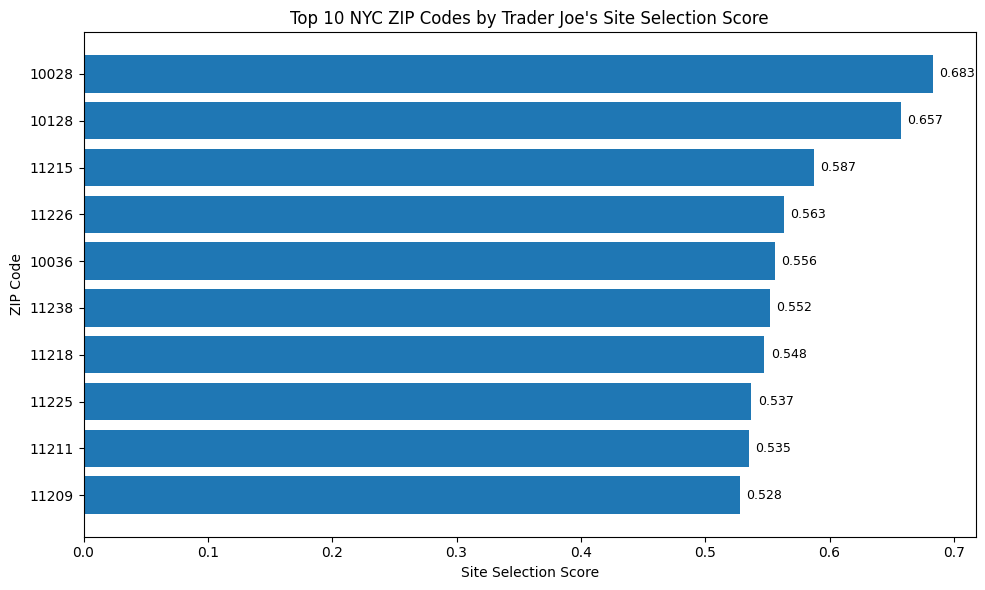

In [5]:
top10_plot = (
    score_df.sort_values("site_selection_score", ascending=False)
    .head(10)
    .copy()
)

top10_plot["label"] = top10_plot["zip_code"].astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_plot["label"][::-1], top10_plot["site_selection_score"][::-1])
ax.set_title("Top 10 NYC ZIP Codes by Trader Joe's Site Selection Score")
ax.set_xlabel("Site Selection Score")
ax.set_ylabel("ZIP Code")

for i, v in enumerate(top10_plot["site_selection_score"][::-1]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / "top_10_score_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

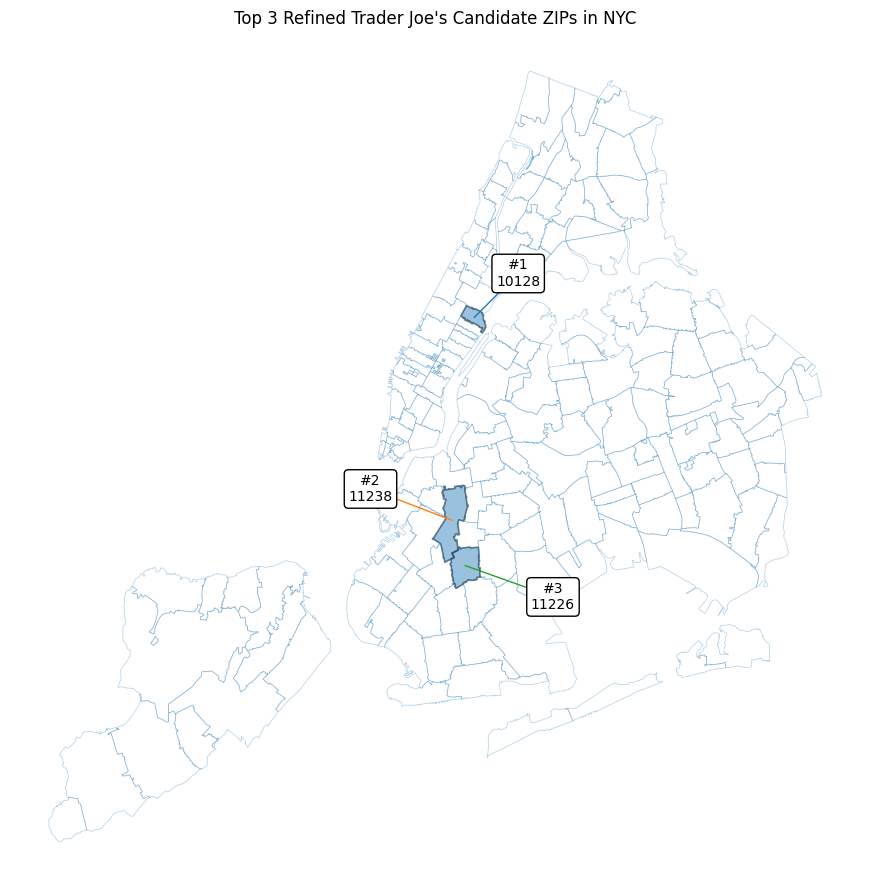

In [23]:
# Top 3 refined candidate map with full NYC ZIP context

# Highlight layer: top 3 refined finalists
top3_map = (
    top10_refine_df.sort_values("refined_rank")
    .head(3)
    .copy()
)

# Background layer: full NYC ZIP universe (pre-screening)
all_zips_bg = gpd.read_file(PROCESSED_DIR / "nyc_model_features.geojson").copy()

# Put both in same CRS
all_zips_bg = all_zips_bg.to_crs(epsg=3857)
top3_map = top3_map.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))

# 1) Plot all NYC ZIP boundaries in background
all_zips_bg.boundary.plot(ax=ax, linewidth=0.5, alpha=0.35)

# 2) Plot top 3 refined polygons on top
top3_map.plot(ax=ax, alpha=0.45, edgecolor="black", linewidth=1.2)

# Custom offsets to avoid overlap
offsets = {
    1: (3500, 3500),    # 10128
    2: (-6500, 2500),   # 11238
    3: (7000, -2500),   # 11226
}

for _, row in top3_map.iterrows():
    rank = int(row["refined_rank"])
    zip_code = str(row["zip_code"])
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    dx, dy = offsets.get(rank, (3000, 3000))

    # connector line
    ax.plot([cx, cx + dx], [cy, cy + dy], linewidth=1)

    # rank + ZIP label
    ax.text(
        cx + dx,
        cy + dy,
        f"#{rank}\n{zip_code}",
        fontsize=10,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black")
    )

# Full-city extent from all NYC ZIPs
all_minx, all_miny, all_maxx, all_maxy = all_zips_bg.total_bounds
x_pad = (all_maxx - all_minx) * 0.05
y_pad = (all_maxy - all_miny) * 0.05

ax.set_xlim(all_minx - x_pad, all_maxx + x_pad)
ax.set_ylim(all_miny - y_pad, all_maxy + y_pad)

ax.set_title("Top 3 Refined Trader Joe's Candidate ZIPs in NYC")
ax.axis("off")

plt.tight_layout()
plt.savefig(MAPS_DIR / "top_3_refined_candidates_map_rank_only.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Top 3 finalists with raw attribute drivers instead of score columns

top10_table = (
    top10_refine_df.sort_values("rank")
    .head(10)
    .copy()
)

desired_cols = [
    "rank",
    "zip_code",
    "boroname",
    "population_density",
    "income_percentile",
    "nearest_tj_distance_miles",
    "subway_station_count",
    "nearest_competitor_miles",
    "competitor_count_1mi",
    "avg_asking_rent_psf",
]

available_cols = [c for c in desired_cols if c in top10_table.columns]
top10_export = top10_table[available_cols].copy()

# Light formatting
for c in ["population_density", "income_percentile", "nearest_tj_distance_miles", "nearest_competitor_miles"]:
    if c in top10_export.columns:
        top10_export[c] = top10_export[c].round(3)

if "avg_asking_rent_psf" in top10_export.columns:
    top10_export["avg_asking_rent_psf"] = top10_export["avg_asking_rent_psf"].round(0)

top10_export.to_csv(TABLES_DIR / "top_3_finalist_raw_attributes.csv", index=False)

top10_export

,rank,zip_code,boroname,population_density,income_percentile,nearest_tj_distance_miles,subway_station_count,nearest_competitor_miles,competitor_count_1mi,avg_asking_rent_psf
4,1,10028,Manhattan,144778.293,0.942,1.231,2.0,0.225,2,259
0,2,10128,Manhattan,130083.870,0.893,1.190,2.0,0.190,1,297
6,3,11215,Brooklyn,32071.913,0.956,1.886,7.0,0.855,1,141
2,4,11226,Brooklyn,76785.420,0.340,3.528,7.0,2.590,0,105
9,5,10036,Manhattan,68396.194,0.694,1.233,4.0,0.470,2,583
1,6,11238,Brooklyn,30184.510,0.859,1.775,7.0,1.207,0,105
3,7,11218,Brooklyn,52361.235,0.660,3.316,3.0,2.285,0,104
5,8,11225,Brooklyn,64633.901,0.393,2.597,7.0,2.006,0,105
8,9,11211,Brooklyn,43923.216,0.733,1.062,6.0,0.277,2,250
7,10,11209,Brooklyn,33481.007,0.641,5.067,3.0,4.259,0,90


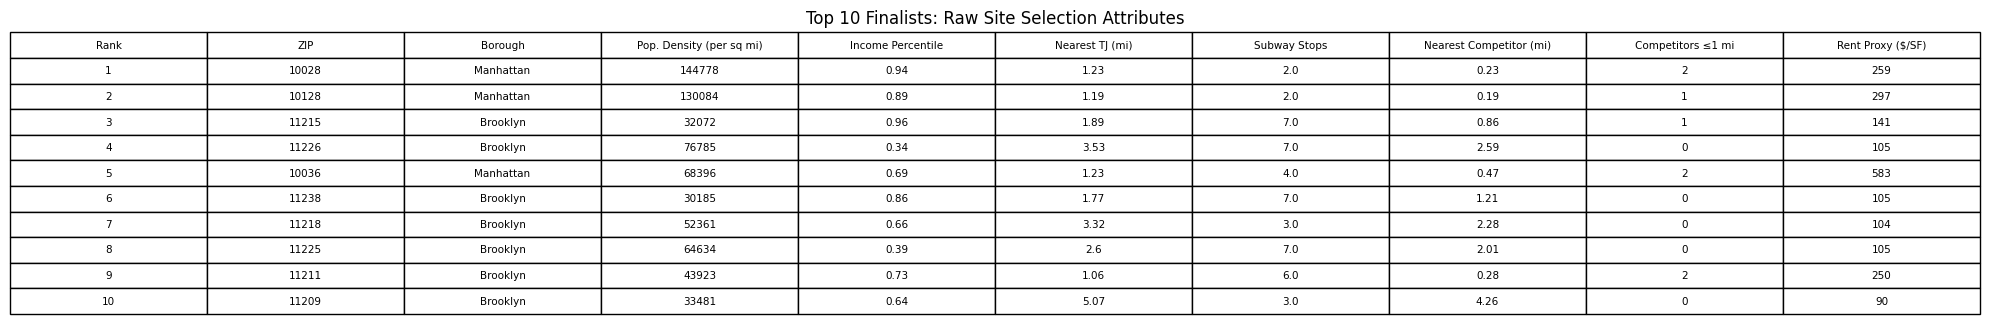

In [8]:
# Top 3 finalists table: raw site-selection attributes with readable headers + units

top10_table = (
    top10_refine_df.sort_values("rank")
    .head(10)
    .copy()
)

desired_cols = [
    "rank",
    "zip_code",
    "boroname",
    "population_density",
    "income_percentile",
    "nearest_tj_distance_miles",
    "subway_station_count",
    "nearest_competitor_miles",
    "competitor_count_1mi",
    "avg_asking_rent_psf",
]

available_cols = [c for c in desired_cols if c in top10_table.columns]
top10_export = top10_table[available_cols].copy()

# Rename columns for readability
top10_export_display = top10_export.rename(columns={
    "rank": "Rank",
    "zip_code": "ZIP",
    "boroname": "Borough",
    "population_density": "Pop. Density (per sq mi)",
    "income_percentile": "Income Percentile",
    "nearest_tj_distance_miles": "Nearest TJ (mi)",
    "subway_station_count": "Subway Stops",
    "nearest_competitor_miles": "Nearest Competitor (mi)",
    "competitor_count_1mi": "Competitors ≤1 mi",
    "avg_asking_rent_psf": "Rent Proxy ($/SF)"
}).copy()

# Format values for display
if "Pop. Density (per sq mi)" in top10_export_display.columns:
    top10_export_display["Pop. Density (per sq mi)"] = (
        top10_export_display["Pop. Density (per sq mi)"].round(0).astype(int)
    )

if "Income Percentile" in top10_export_display.columns:
    top10_export_display["Income Percentile"] = top10_export_display["Income Percentile"].round(2)

if "Nearest TJ (mi)" in top10_export_display.columns:
    top10_export_display["Nearest TJ (mi)"] = top10_export_display["Nearest TJ (mi)"].round(2)

if "Nearest Competitor (mi)" in top10_export_display.columns:
    top10_export_display["Nearest Competitor (mi)"] = top10_export_display["Nearest Competitor (mi)"].round(2)

if "Rent Proxy ($/SF)" in top10_export_display.columns:
    top10_export_display["Rent Proxy ($/SF)"] = (
        top10_export_display["Rent Proxy ($/SF)"].round(0).astype(int)
    )

# Save CSV version too
top10_export_display.to_csv(TABLES_DIR / "top_10_finalist_raw_attributes.csv", index=False)

# Render as image
fig, ax = plt.subplots(figsize=(20, 3.6))
ax.axis("off")

tbl = ax.table(
    cellText=top10_export_display.values,
    colLabels=top10_export_display.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1, 1.6)

plt.title("Top 10 Finalists: Raw Site Selection Attributes", pad=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(TABLES_DIR / "top_10_finalist_raw_attributes_table.png", dpi=300, bbox_inches="tight")
plt.show()

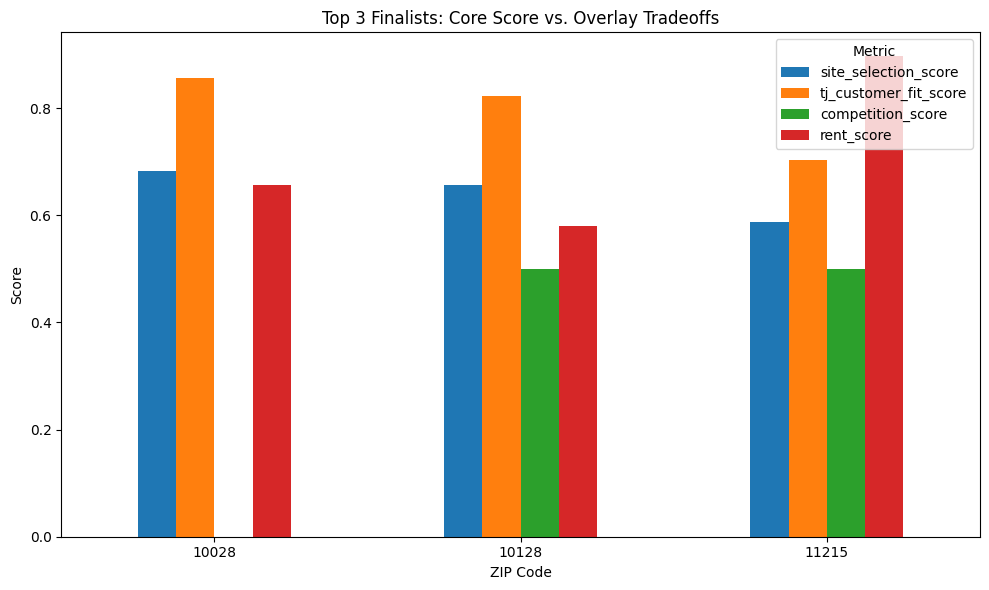

In [9]:
tradeoff_cols = [
    "site_selection_score",
    "tj_customer_fit_score",
    "competition_score",
    "rent_score",
]

top3_tradeoff = (
    top10_refine_df.sort_values("rank")
    .head(3)
    .copy()
)

available_tradeoff = [c for c in tradeoff_cols if c in top3_tradeoff.columns]

plot_df = top3_tradeoff[["zip_code"] + available_tradeoff].copy()
plot_df["zip_code"] = plot_df["zip_code"].astype(str)
plot_df = plot_df.set_index("zip_code")

ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Top 3 Finalists: Core Score vs. Overlay Tradeoffs")
ax.set_xlabel("ZIP Code")
ax.set_ylabel("Score")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS_DIR / "top_3_finalist_tradeoff_chart.png", dpi=300, bbox_inches="tight")
plt.show()

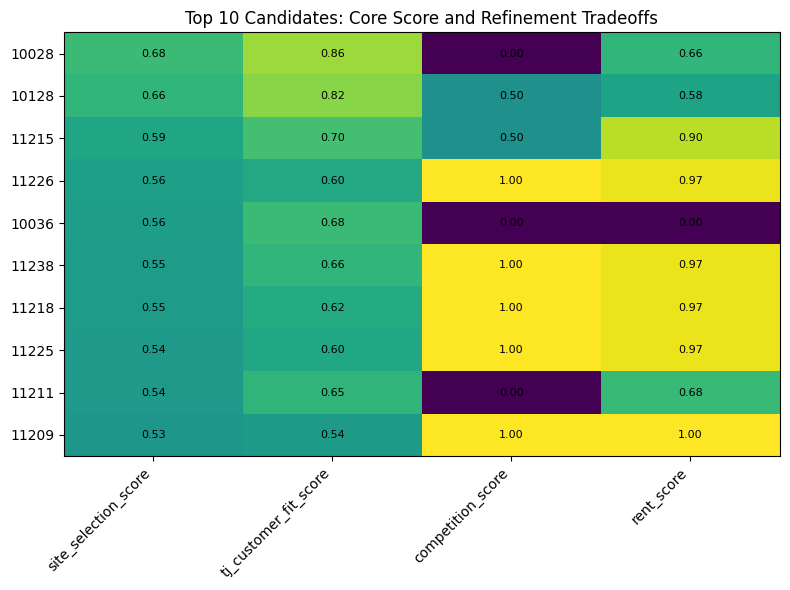

In [10]:
import matplotlib.pyplot as plt
import numpy as np

heatmap_cols = [
    "site_selection_score",
    "tj_customer_fit_score",
    "competition_score",
    "rent_score",
]

heatmap_df = top10_refine_df.sort_values("rank").copy()
available_heatmap = [c for c in heatmap_cols if c in heatmap_df.columns]

plot_df = heatmap_df[["zip_code"] + available_heatmap].copy()
plot_df["zip_code"] = plot_df["zip_code"].astype(str)
plot_df = plot_df.set_index("zip_code")

data = plot_df.values

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(data, aspect="auto")

ax.set_xticks(np.arange(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(plot_df.index)))
ax.set_yticklabels(plot_df.index)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Top 10 Candidates: Core Score and Refinement Tradeoffs")
plt.tight_layout()
plt.savefig(FIGS_DIR / "top_10_tradeoff_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

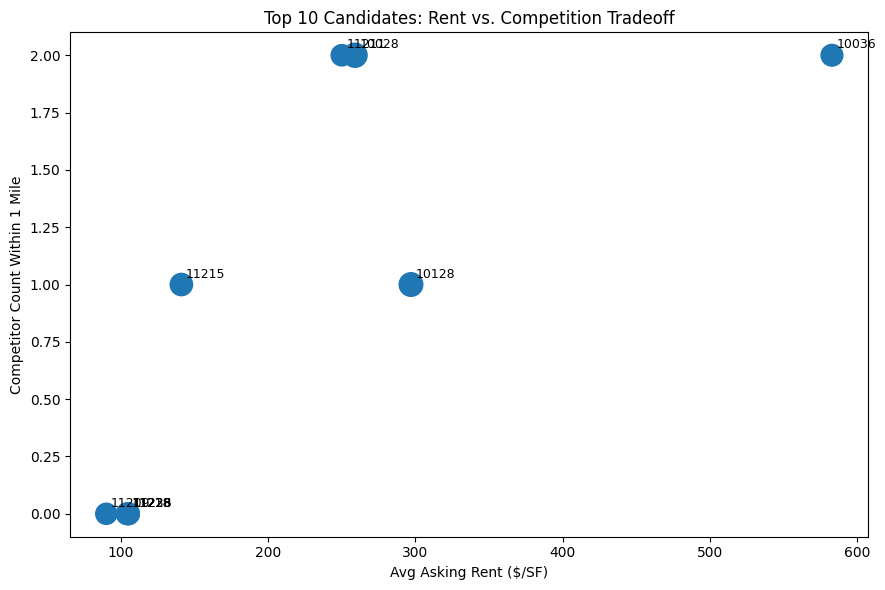

In [11]:
scatter_df = top10_refine_df.sort_values("rank").copy()

required = ["avg_asking_rent_psf", "competitor_count_1mi", "site_selection_score", "zip_code"]
scatter_df = scatter_df[[c for c in required if c in scatter_df.columns]].dropna().copy()

fig, ax = plt.subplots(figsize=(9, 6))

sizes = 300 * (scatter_df["site_selection_score"] / scatter_df["site_selection_score"].max())

ax.scatter(
    scatter_df["avg_asking_rent_psf"],
    scatter_df["competitor_count_1mi"],
    s=sizes
)

for _, row in scatter_df.iterrows():
    ax.text(
        row["avg_asking_rent_psf"] + 3,
        row["competitor_count_1mi"] + 0.03,
        str(row["zip_code"]),
        fontsize=9
    )

ax.set_xlabel("Avg Asking Rent ($/SF)")
ax.set_ylabel("Competitor Count Within 1 Mile")
ax.set_title("Top 10 Candidates: Rent vs. Competition Tradeoff")

plt.tight_layout()
plt.savefig(FIGS_DIR / "top_10_rent_vs_competition_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

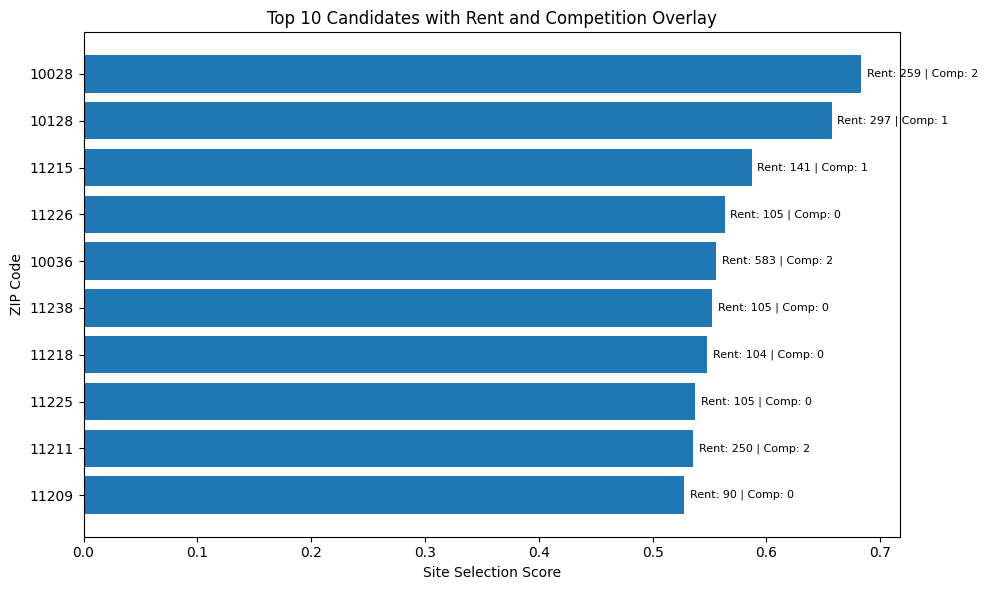

In [12]:
bar_df = top10_refine_df.sort_values("rank").copy()
bar_df["zip_code"] = bar_df["zip_code"].astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(bar_df["zip_code"][::-1], bar_df["site_selection_score"][::-1])

for i, (_, row) in enumerate(bar_df[::-1].iterrows()):
    label = []
    if "avg_asking_rent_psf" in row.index and pd.notna(row["avg_asking_rent_psf"]):
        label.append(f"Rent: {row['avg_asking_rent_psf']:.0f}")
    if "competitor_count_1mi" in row.index and pd.notna(row["competitor_count_1mi"]):
        label.append(f"Comp: {row['competitor_count_1mi']:.0f}")
    ax.text(
        row["site_selection_score"] + 0.005,
        i,
        " | ".join(label),
        va="center",
        fontsize=8
    )

ax.set_title("Top 10 Candidates with Rent and Competition Overlay")
ax.set_xlabel("Site Selection Score")
ax.set_ylabel("ZIP Code")

plt.tight_layout()
plt.savefig(FIGS_DIR / "top_10_score_bar_with_refinements.png", dpi=300, bbox_inches="tight")
plt.show()

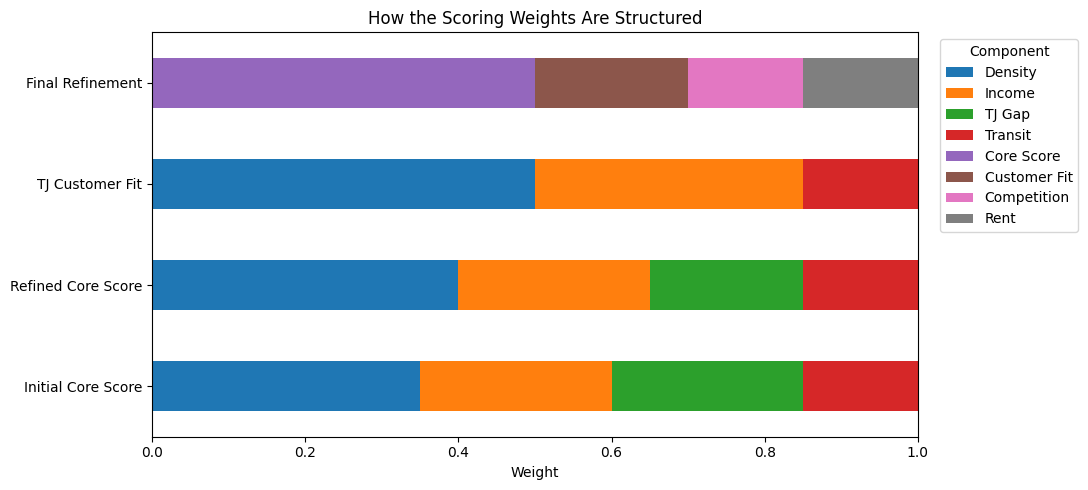

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

weight_df = pd.DataFrame({
    "Model": [
        "Initial Core Score",
        "Refined Core Score",
        "TJ Customer Fit",
        "Final Refinement"
    ],
    "Density": [0.35, 0.40, 0.50, 0.00],
    "Income": [0.25, 0.25, 0.35, 0.00],
    "TJ Gap": [0.25, 0.20, 0.00, 0.00],
    "Transit": [0.15, 0.15, 0.15, 0.00],
    "Core Score": [0.00, 0.00, 0.00, 0.50],
    "Customer Fit": [0.00, 0.00, 0.00, 0.20],
    "Competition": [0.00, 0.00, 0.00, 0.15],
    "Rent": [0.00, 0.00, 0.00, 0.15],
})

plot_cols = ["Density", "Income", "TJ Gap", "Transit", "Core Score", "Customer Fit", "Competition", "Rent"]
plot_df = weight_df.set_index("Model")[plot_cols]

ax = plot_df.plot(kind="barh", stacked=True, figsize=(11, 5))
ax.set_title("How the Scoring Weights Are Structured")
ax.set_xlabel("Weight")
ax.set_ylabel("")
ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGS_DIR / "weight_architecture_chart.png", dpi=300, bbox_inches="tight")
plt.show()

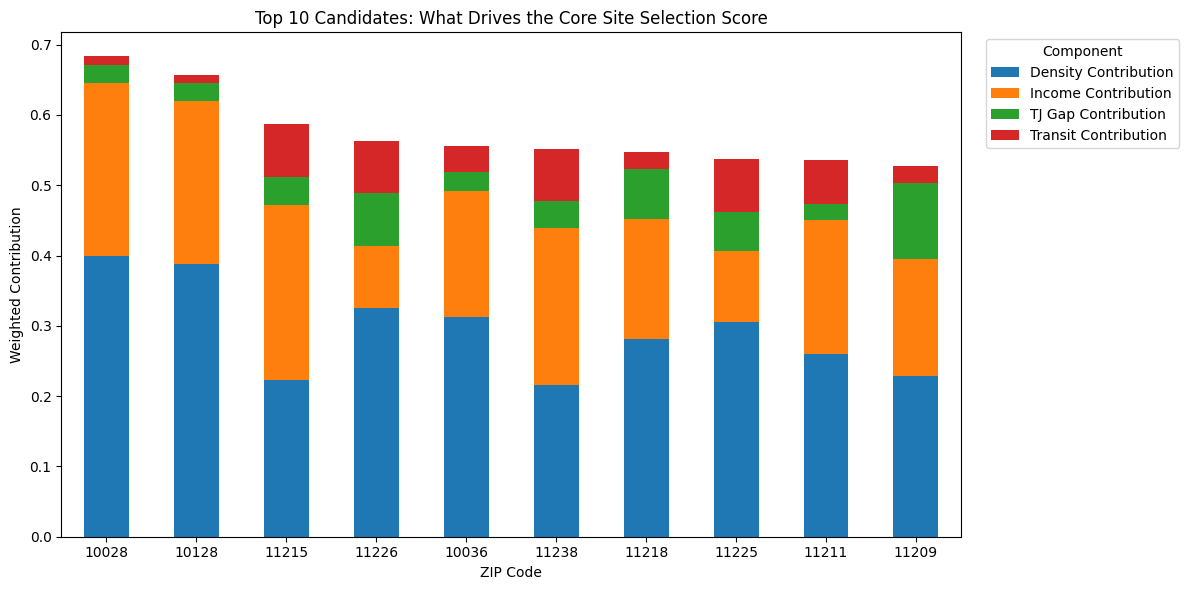

In [14]:
core_contrib_df = score_df.sort_values("site_selection_score", ascending=False).head(10).copy()
core_contrib_df["zip_code"] = core_contrib_df["zip_code"].astype(str)

# Use the final refined core weights from your notebook
core_contrib_df["Density Contribution"] = 0.40 * core_contrib_df["density_score"]
core_contrib_df["Income Contribution"] = 0.25 * core_contrib_df["income_score"]
core_contrib_df["TJ Gap Contribution"] = 0.20 * core_contrib_df["tj_gap_score"]
core_contrib_df["Transit Contribution"] = 0.15 * core_contrib_df["transit_score"]

plot_df = core_contrib_df.set_index("zip_code")[
    ["Density Contribution", "Income Contribution", "TJ Gap Contribution", "Transit Contribution"]
]

ax = plot_df.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Top 10 Candidates: What Drives the Core Site Selection Score")
ax.set_xlabel("ZIP Code")
ax.set_ylabel("Weighted Contribution")
ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS_DIR / "top_10_core_score_contributions.png", dpi=300, bbox_inches="tight")
plt.show()

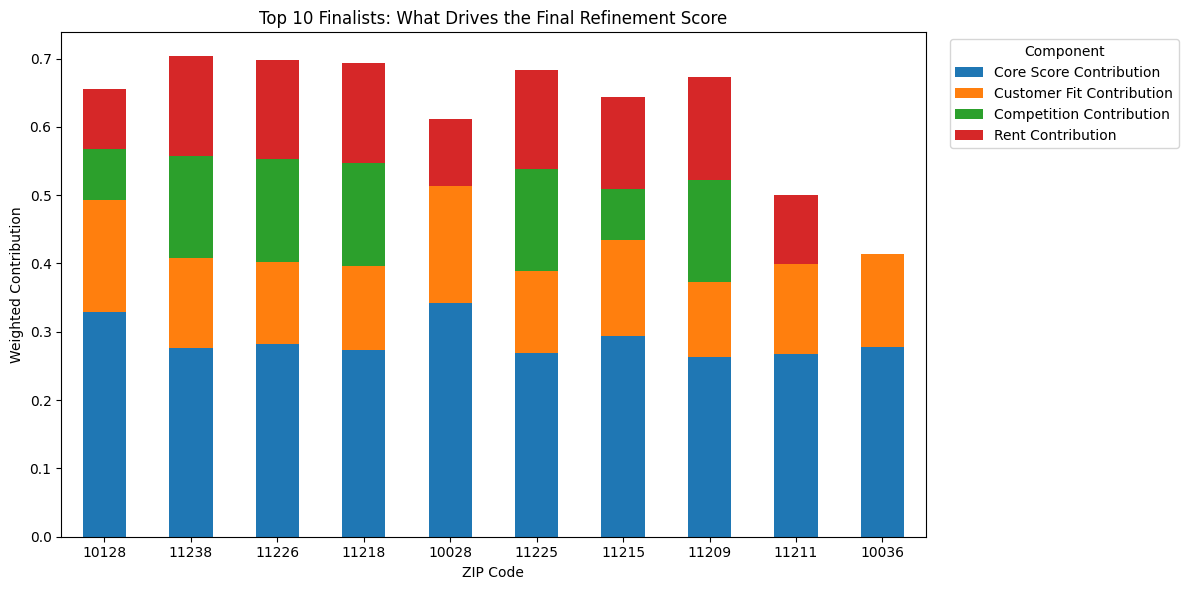

In [15]:
refine_df = top10_refine_df.sort_values("final_refinement_score", ascending=False).copy()
refine_df["zip_code"] = refine_df["zip_code"].astype(str)

refine_df["Core Score Contribution"] = 0.50 * refine_df["site_selection_score"]
refine_df["Customer Fit Contribution"] = 0.20 * refine_df["tj_customer_fit_score"]
refine_df["Competition Contribution"] = 0.15 * refine_df["competition_score"]
refine_df["Rent Contribution"] = 0.15 * refine_df["rent_score"]

plot_df = refine_df.set_index("zip_code")[
    ["Core Score Contribution", "Customer Fit Contribution", "Competition Contribution", "Rent Contribution"]
]

ax = plot_df.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Top 10 Finalists: What Drives the Final Refinement Score")
ax.set_xlabel("ZIP Code")
ax.set_ylabel("Weighted Contribution")
ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS_DIR / "top_10_final_refinement_contributions.png", dpi=300, bbox_inches="tight")
plt.show()

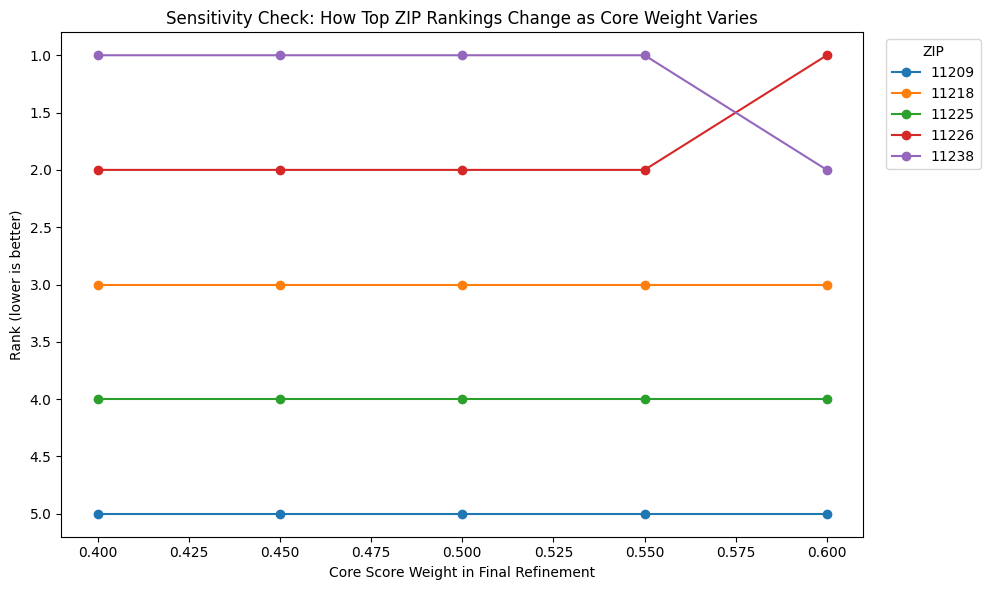

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

sensitivity_rows = []

core_weights = [0.40, 0.45, 0.50, 0.55, 0.60]

for w_core in core_weights:
    # keep competition and rent fixed at 0.15 each
    # allocate the remainder to customer fit
    w_comp = 0.15
    w_rent = 0.15
    w_fit = 1.0 - w_core - w_comp - w_rent

    temp = top10_refine_df.copy()
    temp["sensitivity_score"] = (
        w_core * temp["site_selection_score"] +
        w_fit * temp["tj_customer_fit_score"] +
        w_comp * temp["competition_score"] +
        w_rent * temp["rent_score"]
    )

    temp = temp.sort_values("sensitivity_score", ascending=False).reset_index(drop=True)
    temp["sensitivity_rank"] = range(1, len(temp) + 1)

    for _, row in temp.head(5).iterrows():
        sensitivity_rows.append({
            "Core Weight": w_core,
            "ZIP": str(row["zip_code"]),
            "Rank": row["sensitivity_rank"]
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

pivot_df = sensitivity_df.pivot(index="Core Weight", columns="ZIP", values="Rank")

ax = pivot_df.plot(marker="o", figsize=(10, 6))
ax.set_title("Sensitivity Check: How Top ZIP Rankings Change as Core Weight Varies")
ax.set_xlabel("Core Score Weight in Final Refinement")
ax.set_ylabel("Rank (lower is better)")
ax.invert_yaxis()
ax.legend(title="ZIP", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGS_DIR / "weight_sensitivity_rank_chart.png", dpi=300, bbox_inches="tight")
plt.show()

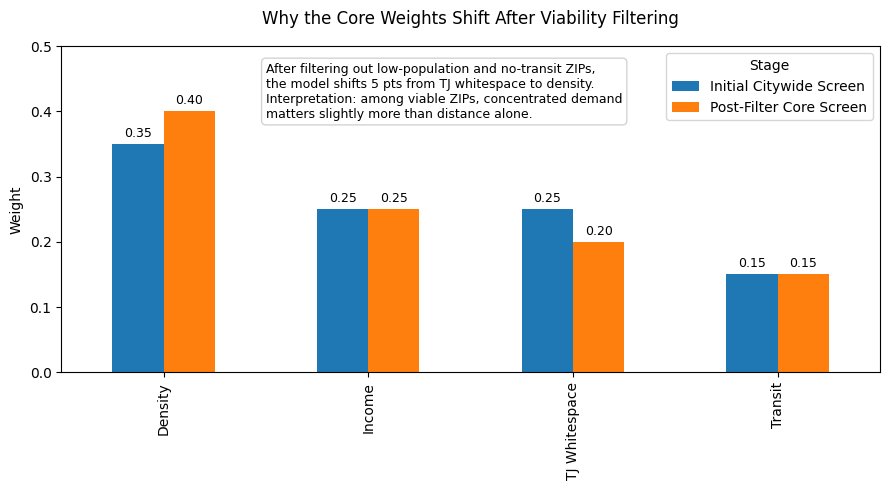

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Compare pre- and post-viability-filter core weights
weight_compare = pd.DataFrame({
    "Component": ["Density", "Income", "TJ Whitespace", "Transit"],
    "Initial Citywide Screen": [0.35, 0.25, 0.25, 0.15],
    "Post-Filter Core Screen": [0.40, 0.25, 0.20, 0.15],
})

plot_df = weight_compare.set_index("Component")

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Why the Core Weights Shift After Viability Filtering", pad=16)
ax.set_xlabel("")
ax.set_ylabel("Weight")
ax.set_ylim(0, 0.5)
ax.legend(title="Stage")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

# Add short explanatory note inside chart
ax.text(
    0.25, 0.95,
    "After filtering out low-population and no-transit ZIPs,\n"
    "the model shifts 5 pts from TJ whitespace to density.\n"
    "Interpretation: among viable ZIPs, concentrated demand\n"
    "matters slightly more than distance alone.",
    transform=ax.transAxes,
    fontsize=9,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="lightgray")
)

plt.tight_layout()
plt.savefig(FIGS_DIR / "core_weight_shift_pre_vs_post_filter.png", dpi=300, bbox_inches="tight")
plt.show()

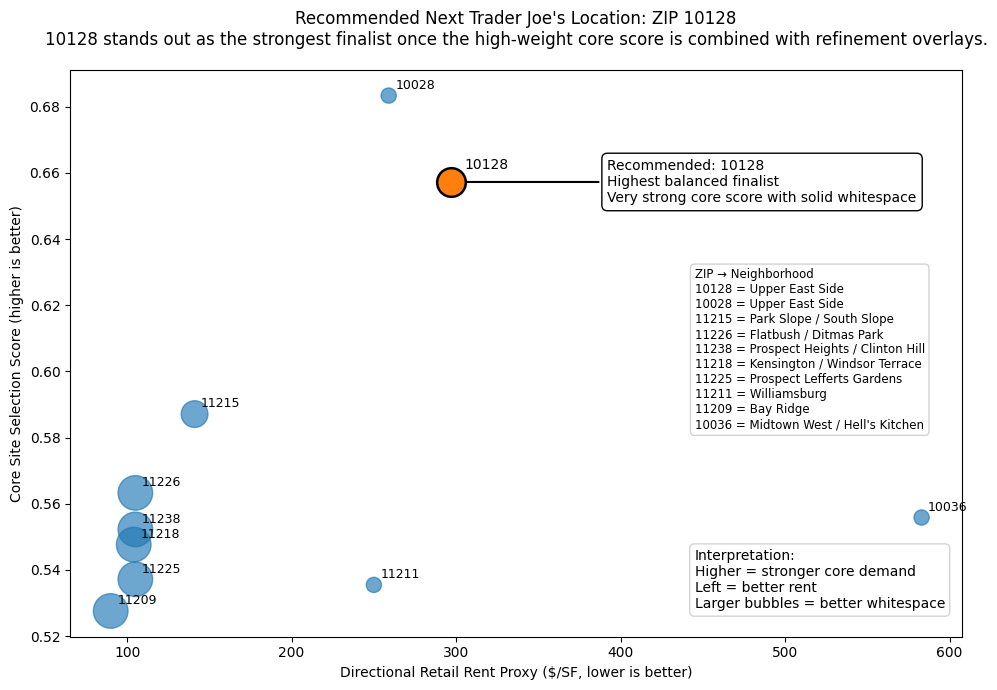

In [18]:
# Executive summary bubble chart with 10128 as recommended option

import matplotlib.pyplot as plt
import pandas as pd

plot_df = top10_refine_df.sort_values("rank").copy()
plot_df["zip_code"] = plot_df["zip_code"].astype(str)

required_cols = ["zip_code", "site_selection_score", "avg_asking_rent_psf"]
required_cols = [c for c in required_cols if c in plot_df.columns]

if "competition_score" in plot_df.columns:
    bubble_col = "competition_score"
    bubble_label = "Bubble size = Competition Score (larger = better whitespace)"
elif "nearest_competitor_miles" in plot_df.columns:
    bubble_col = "nearest_competitor_miles"
    bubble_label = "Bubble size = Distance to Nearest Competitor (larger = better)"
else:
    bubble_col = None
    bubble_label = None

use_cols = required_cols + ([bubble_col] if bubble_col else [])
plot_df = plot_df[use_cols].dropna().copy()

rec_zip = "10128"
rec_df = plot_df[plot_df["zip_code"] == rec_zip].copy()
other_df = plot_df[plot_df["zip_code"] != rec_zip].copy()

fig, ax = plt.subplots(figsize=(10, 7))

# Bubble sizes
if bubble_col:
    scaled_sizes = 120 + 500 * (plot_df[bubble_col] / plot_df[bubble_col].max())
    size_map = dict(zip(plot_df["zip_code"], scaled_sizes))
    other_sizes = other_df["zip_code"].map(size_map)
else:
    other_sizes = 100
    size_map = {}

# Plot all other candidates
ax.scatter(
    other_df["avg_asking_rent_psf"],
    other_df["site_selection_score"],
    s=other_sizes,
    alpha=0.65
)

# Label other ZIPs
for _, row in other_df.iterrows():
    ax.text(
        row["avg_asking_rent_psf"] + 4,
        row["site_selection_score"] + 0.002,
        row["zip_code"],
        fontsize=9
    )

# Highlight recommended point: 10128
if not rec_df.empty:
    r = rec_df.iloc[0]
    rec_size = size_map[r["zip_code"]] if bubble_col else 260

    ax.scatter(
        [r["avg_asking_rent_psf"]],
        [r["site_selection_score"]],
        s=rec_size * 1.15,
        edgecolor="black",
        linewidth=1.8,
        zorder=5
    )
    ax.text(
    r["avg_asking_rent_psf"] + 8,
    r["site_selection_score"] + 0.004,
    r["zip_code"],
    fontsize=10
    )

    callout = (
        "Recommended: 10128\n"
        "Highest balanced finalist\n"
        "Very strong core score with solid whitespace"
    )

    ax.annotate(
        callout,
        xy=(r["avg_asking_rent_psf"], r["site_selection_score"]),
        xytext=(r["avg_asking_rent_psf"] + 95, r["site_selection_score"]),
        arrowprops=dict(arrowstyle="->", lw=1.5),
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black"),
        fontsize=10,
        ha="left",
        va="center"
    )
 

# Reference lines
x_med = plot_df["avg_asking_rent_psf"].median()
y_med = plot_df["site_selection_score"].median()


# Labels and title
ax.set_xlabel("Directional Retail Rent Proxy ($/SF, lower is better)")
ax.set_ylabel("Core Site Selection Score (higher is better)")
ax.set_title(
    "Recommended Next Trader Joe's Location: ZIP 10128\n"
    "10128 stands out as the strongest finalist once the high-weight core score is combined with refinement overlays.",
    pad=18
)

note = "Interpretation: higher = stronger core demand | left = better rent"
if bubble_label:
    note += f" | {bubble_label}"

ax.text(
    0.70, 0.1,
    "Interpretation:\nHigher = stronger core demand\nLeft = better rent\nLarger bubbles = better whitespace",
    transform=ax.transAxes,
    fontsize=10,
    ha="left",
    va="center",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="lightgray")
)
zip_name_legend = (
    "ZIP → Neighborhood\n"
    "10128 = Upper East Side\n"
    "10028 = Upper East Side\n"
    "11215 = Park Slope / South Slope\n"
    "11226 = Flatbush / Ditmas Park\n"
    "11238 = Prospect Heights / Clinton Hill\n"
    "11218 = Kensington / Windsor Terrace\n"
    "11225 = Prospect Lefferts Gardens\n"
    "11211 = Williamsburg\n"
    "11209 = Bay Ridge\n"
    "10036 = Midtown West / Hell's Kitchen"
)

ax.text(
    0.70, 0.65,
    zip_name_legend,
    transform=ax.transAxes,
    fontsize=8.5,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="lightgray")
)

plt.tight_layout()
plt.savefig(FIGS_DIR / "executive_summary_bubble_10128.png", dpi=300, bbox_inches="tight")
plt.show()

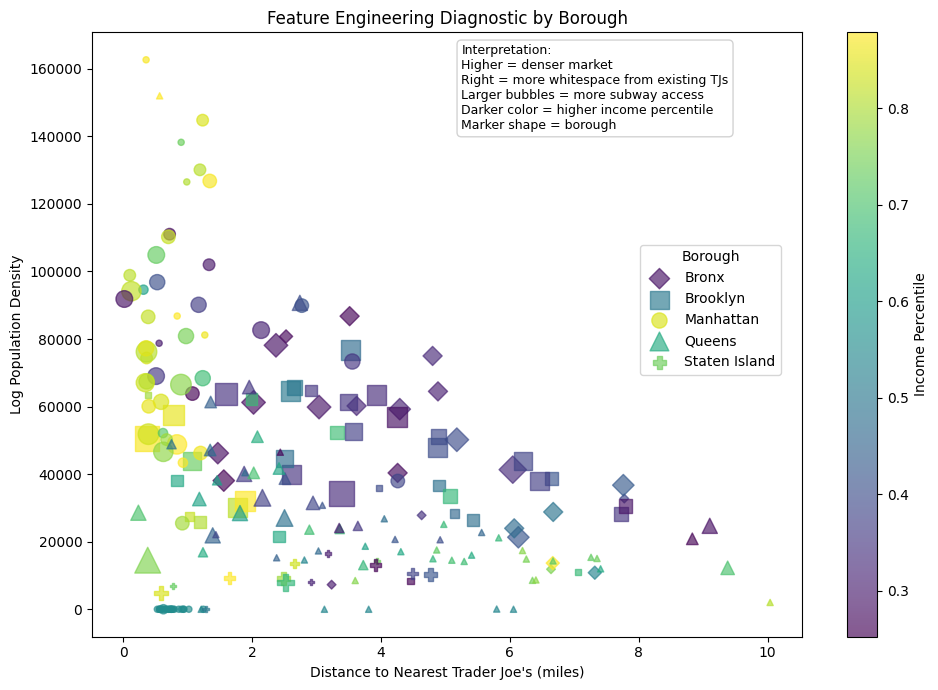

In [19]:
# Feature engineering diagnostic plot by borough

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

feature_df = gpd.read_file(PROCESSED_DIR / "nyc_model_features.geojson").copy()
feature_df["zip_code"] = feature_df["zip_code"].astype(str)

plot_df = feature_df.dropna(subset=[
    "nearest_tj_distance_miles",
    "population_density",
    "income_percentile",
    "subway_station_count",
    "boroname"
]).copy()

# Bubble sizes from subway counts
plot_df["bubble_size"] = 20 + 25 * plot_df["subway_station_count"].clip(lower=0)

# Marker map by borough
marker_map = {
    "Manhattan": "o",
    "Brooklyn": "s",
    "Queens": "^",
    "Bronx": "D",
    "Staten Island": "P",
}

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each borough separately so marker shapes differ
sc = None
for borough, subdf in plot_df.groupby("boroname"):
    marker = marker_map.get(borough, "o")
    sc = ax.scatter(
        subdf["nearest_tj_distance_miles"],
        subdf["population_density"],
        s=subdf["bubble_size"],
        c=subdf["income_percentile"],
        marker=marker,
        alpha=0.65,
        label=borough
    )

# Colorbar for income percentile
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Income Percentile")

ax.set_xlabel("Distance to Nearest Trader Joe's (miles)")
ax.set_ylabel("Log Population Density")
ax.set_title("Feature Engineering Diagnostic by Borough")

# Legend for borough marker shapes
legend = ax.legend(
    title="Borough",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.66),
    frameon=True
)

# Interpretation box
ax.text(
    0.52, 0.98,
    "Interpretation:\n"
    "Higher = denser market\n"
    "Right = more whitespace from existing TJs\n"
    "Larger bubbles = more subway access\n"
    "Darker color = higher income percentile\n"
    "Marker shape = borough",
    transform=ax.transAxes,
    fontsize=9,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="lightgray")
)

plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_engineering_borough_plot.png", dpi=300, bbox_inches="tight")
plt.show()

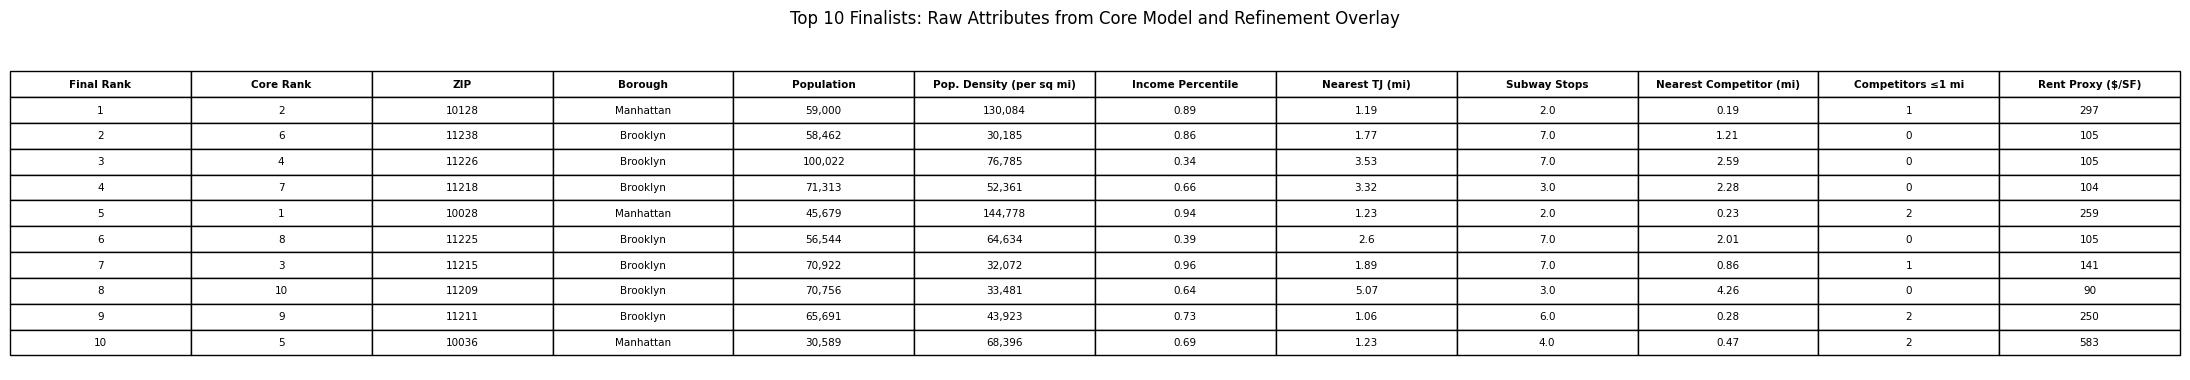

In [25]:
# Top 10 finalists table: raw attributes only (no score columns)

import matplotlib.pyplot as plt
import pandas as pd

# Sort by final refinement ranking
top10_table = (
    top10_refine_df.sort_values("refined_rank")
    .head(10)
    .copy()
)

# Keep only non-score attributes
desired_cols = [
    "refined_rank",
    "rank",                       # original core rank
    "zip_code",
    "boroname",
    "total_population",
    "population_density",
    "income_percentile",
    "nearest_tj_distance_miles",
    "subway_station_count",
    "nearest_competitor_miles",
    "competitor_count_1mi",
    "avg_asking_rent_psf",
]

available_cols = [c for c in desired_cols if c in top10_table.columns]
top10_export = top10_table[available_cols].copy()

# Rename columns for display
top10_export_display = top10_export.rename(columns={
    "refined_rank": "Final Rank",
    "rank": "Core Rank",
    "zip_code": "ZIP",
    "boroname": "Borough",
    "total_population": "Population",
    "population_density": "Pop. Density (per sq mi)",
    "income_percentile": "Income Percentile",
    "nearest_tj_distance_miles": "Nearest TJ (mi)",
    "subway_station_count": "Subway Stops",
    "nearest_competitor_miles": "Nearest Competitor (mi)",
    "competitor_count_1mi": "Competitors ≤1 mi",
    "avg_asking_rent_psf": "Rent Proxy ($/SF)"
}).copy()

# Format values for readability
if "Population" in top10_export_display.columns:
    top10_export_display["Population"] = (
        top10_export_display["Population"].round(0).astype(int).map(lambda x: f"{x:,}")
    )

if "Pop. Density (per sq mi)" in top10_export_display.columns:
    top10_export_display["Pop. Density (per sq mi)"] = (
        top10_export_display["Pop. Density (per sq mi)"].round(0).astype(int).map(lambda x: f"{x:,}")
    )

if "Income Percentile" in top10_export_display.columns:
    top10_export_display["Income Percentile"] = top10_export_display["Income Percentile"].round(2)

if "Nearest TJ (mi)" in top10_export_display.columns:
    top10_export_display["Nearest TJ (mi)"] = top10_export_display["Nearest TJ (mi)"].round(2)

if "Nearest Competitor (mi)" in top10_export_display.columns:
    top10_export_display["Nearest Competitor (mi)"] = top10_export_display["Nearest Competitor (mi)"].round(2)

if "Rent Proxy ($/SF)" in top10_export_display.columns:
    top10_export_display["Rent Proxy ($/SF)"] = (
        top10_export_display["Rent Proxy ($/SF)"].round(0).astype(int)
    )

# Save CSV
top10_export_display.to_csv(TABLES_DIR / "top_10_final_model_overlay_raw_attributes.csv", index=False)

# Render PNG table
fig, ax = plt.subplots(figsize=(22, 4.2))
ax.axis("off")

tbl = ax.table(
    cellText=top10_export_display.values,
    colLabels=top10_export_display.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1, 1.6)

# Optional: make header row bold
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

plt.title("Top 10 Finalists: Raw Attributes from Core Model and Refinement Overlay", pad=24)
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    TABLES_DIR / "top_10_final_model_overlay_raw_attributes_table.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#Summary
1. Loaded the finalized processed outputs from prior notebooks so all charts, maps, and tables could be reproduced from saved files.
2. Built presentation-ready visuals for the report, including ranking charts, candidate maps, refinement comparisons, and raw-attribute tables.
3. Exported final figures, maps, and tables to the outputs/ directories for use in the written case-study report.
4. Used these visuals to translate the modeling workflow into a business-facing recommendation and supporting exhibits.